# Main idea

Sample the intensity on the linear segment, connnecting two annotations. Get the radius of the spherical geometry mask as the point with the minimum intensity

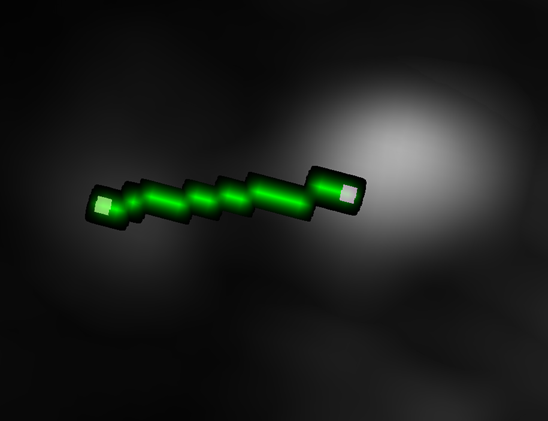

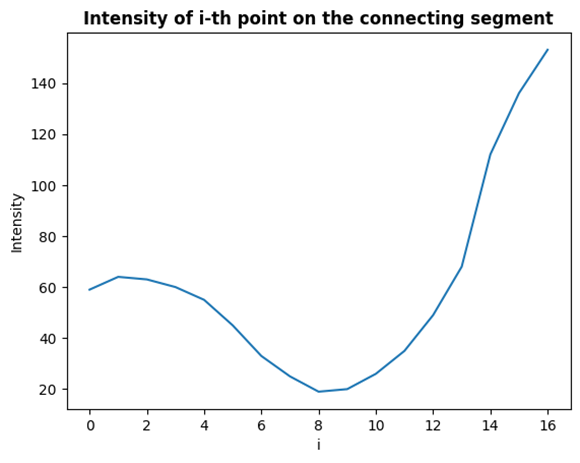

Here, the sphere radius would be equal to the distance of point no. 8 to the annotation at point no 8 in pixels.

# Imports & data loading

In [18]:
from lineagetree import read_from_mastodon
import numpy as np
import h5py
from scipy.spatial.distance import cdist
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion
from tqdm import tqdm
from skimage.segmentation import watershed

# CUSTOM FUNCTIONS
import watermasks.utils as utils
import watermasks.main as main

In [ ]:
# --- LOAD DIRECTORIES FOR DATA AND FILES ---
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = utils.paths('JR_22-10-18')

VIEW='0' # Choose dataset view

# IMPORT REG. MATRICES AND LINEAGETREE
R_of_t = utils.import_registration_mats_multiview(path_xml, 0, 500)
lT = read_from_mastodon(path_mast)

TP = 500 # Choose timepoint

# IMPORT INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    raw_image = f5[f't00{TP}'][f's0{VIEW}']['2']['cells'][:]

# Data manipulation & image proccessing

In [20]:
# CALCULATE SCALING FACTORS
shape_full_h5 = np.array([300, 1888, 2100]) # for no downscaling (0-th level of the hdf5), (as measured in T7_3 data (dir = H:))
shape_raw_image = np.array(np.shape(raw_image))
scaling = shape_raw_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_raw_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS AT CURRENT TIMEPOIN
seeds_pos, seeds_array = main.get_seeds(lT, TP, VIEW, R_of_t, scaling, raw_image)

full image shape = [ 300 1888 2100]
2nd h5 layer has shape = [300 472 525] 
-scaling ratio is [z, y, x] = [1.   0.25 0.25]


In [21]:
# IMAGE PRE-PROCCESSING 
im_gauss = gaussian_filter(raw_image, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)
erosion = grey_erosion(im_gauss_median, size=7)
im_for_ws = im_gauss_median - erosion
im_for_ws = gaussian_filter(im_for_ws, sigma = 1)

# Main loop

In [22]:
from importlib import reload

In [23]:
reload(main)

<module 'watermasks.main' from 'D:\\users\\Dimitris pt 2\\Stardist-watershed\\watermasks\\src\\watermasks\\main.py'>

In [26]:
# SOME SIMPLE FUNCTIONS TO CONTROL VOLUME WITH INTENSITY (EXPERIMENTAL)
def min_vol_of_inte(intensity, mi=100, mv=100, Mi=400, Mv=200):
	return (Mv-mv)/(Mi-mi)*(intensity - Mi) + Mv
def max_vol_of_inte(intensity, mi=100, mv=300, Mi=400, Mv = 1000):
	return (Mv-mv)/(Mi-mi)*(intensity - Mi) + Mv

updated_watershed = np.zeros_like(im_for_ws)
all_seeds = set(np.unique(seeds_array)) - {0}
dist_arr = cdist([sp for sp in seeds_pos.values()], [sp for sp in seeds_pos.values()])

for label in tqdm(all_seeds, desc=f'label = '):
# for label in tqdm([32], desc='label = '):
	neighb_labels, nei_dist = main.get_n_th_closest_labels(dist_arr, label, 4)
	neigh_pos = [seeds_pos[labb] for labb in neighb_labels]

	crop_array = main.crop_to_include_nei(seeds_array, neigh_pos)
	crop_image = main.crop_to_include_nei(im_for_ws, neigh_pos)

	labels_in_crop_array = set(np.unique(crop_array)) - {0}
	center_pos = [item for row in np.where(crop_array==label) for item in row] 
	inten_at_seed = crop_image[center_pos[0], center_pos[1], center_pos[2]]

	sph_rad = main.int_inf_rad(raw_image, label, neigh_pos[0], [neigh_pos[i] for i in range(1, len(neigh_pos))], seeds_pos)
	# use the raw image as input so you get mere detailed information of intensity. 
	geometry_mask = main.sphere_mask(crop_array.shape, center_pos, sph_rad)
	sph_vol = 4/3*np.pi*sph_rad**3 # maximum volume of the region

	for threshold in range(10, inten_at_seed)[::-10]:
		intensity_mask = crop_image > threshold
		combine_masks = intensity_mask & geometry_mask
		small_watershed = watershed(crop_image, crop_array, mask=combine_masks)

		vols = {}
		labels, volumes = np.unique(small_watershed, return_counts=True)
		vols = dict(zip(labels, volumes))
		# print(f'volume = {vols[label]} @ int_thersh = {threshold}, shp_rad = {sph_rad}')

		if sph_rad <= 12:
			if label in small_watershed and vols[label] > min(0.75*sph_vol, 500):
			# by construction of the mask, the maximum volume of the region, is that of the sphere
				main.update_image(updated_watershed, small_watershed, seeds_pos[label], center_pos, label)
				break
		
		else:
			min_vol = min_vol_of_inte(inten_at_seed)
			max_vol = max_vol_of_inte(inten_at_seed)
			if label in small_watershed and min_vol < vols[label] < max_vol:
				main.update_image(updated_watershed, small_watershed, seeds_pos[label], center_pos, label)
				break

label = : 100%|██████████| 399/399 [00:54<00:00,  7.29it/s]


In [25]:
import napari
viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_labels(seeds_array)
viewer.add_labels(updated_watershed)

<Labels layer 'updated_watershed' at 0x1bbd7da0430>

# Results

For tmp = 500, we get results like these:

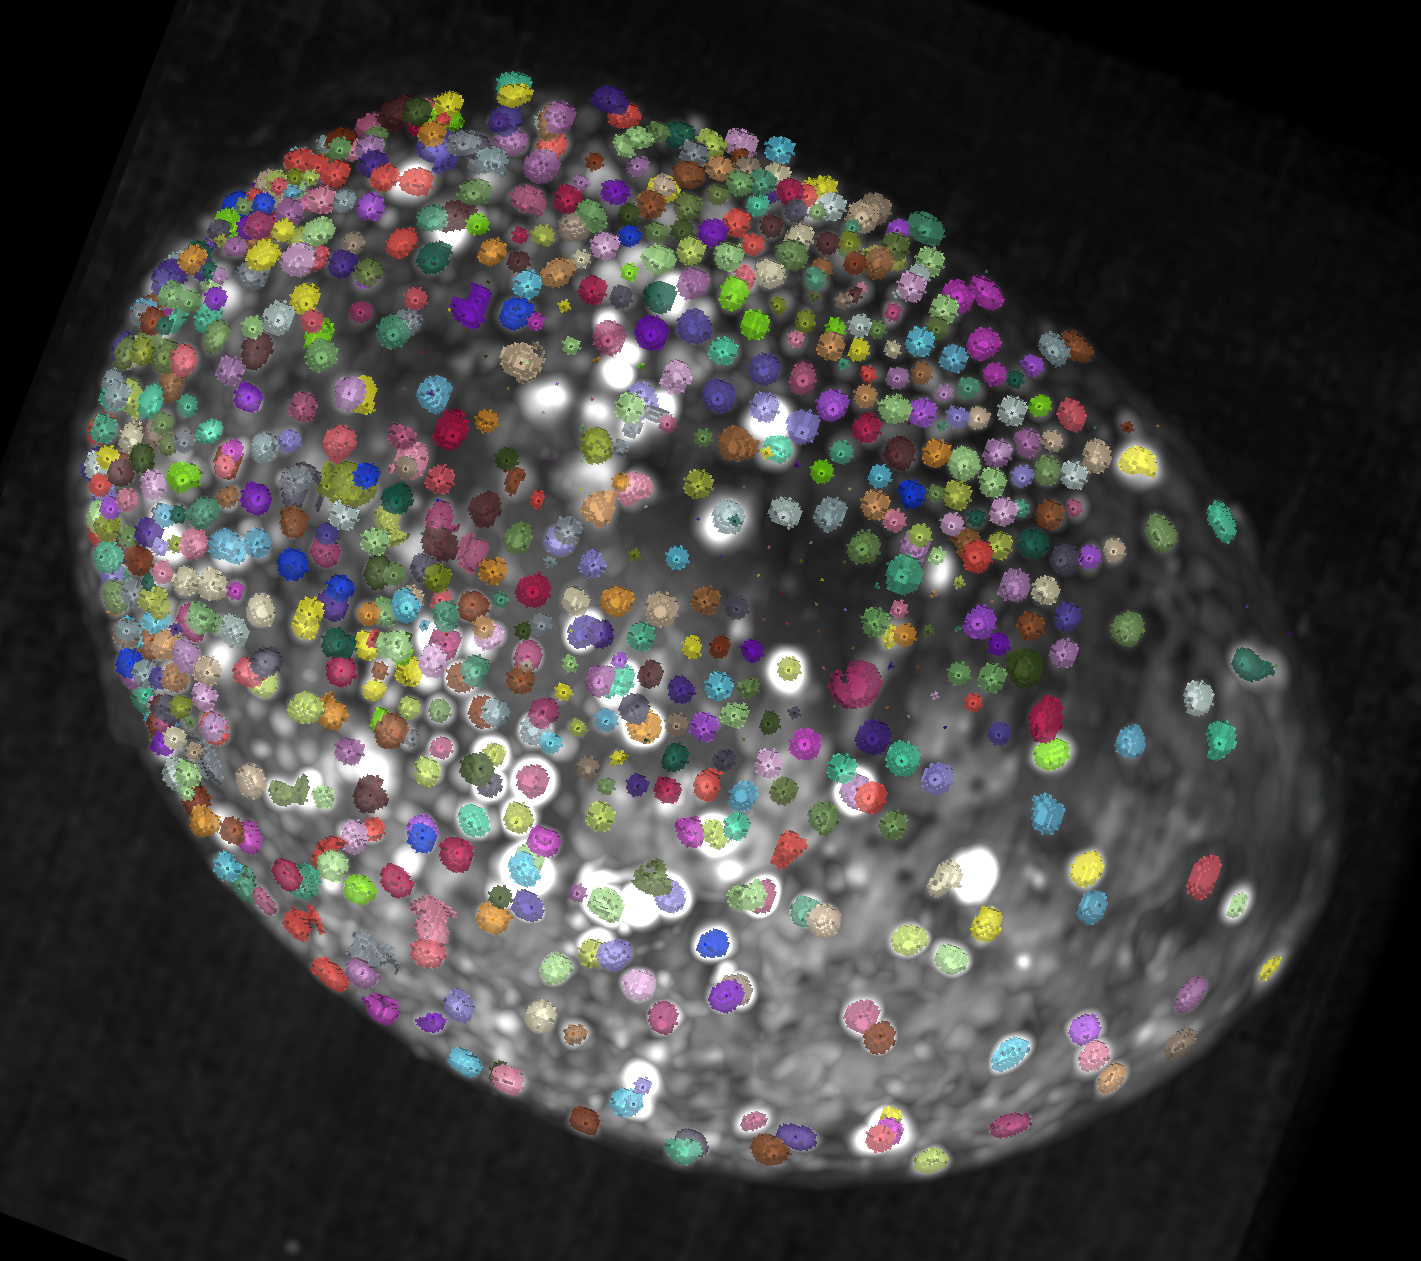

Problems : there are some spheres with radius = 1, resulting to tiny regions. This is a bug needed to be fixed.

Also, is some rare cases, it does not function as expected:
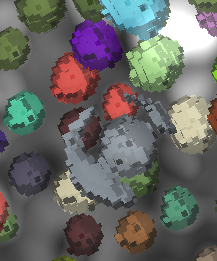

For tmp = 300

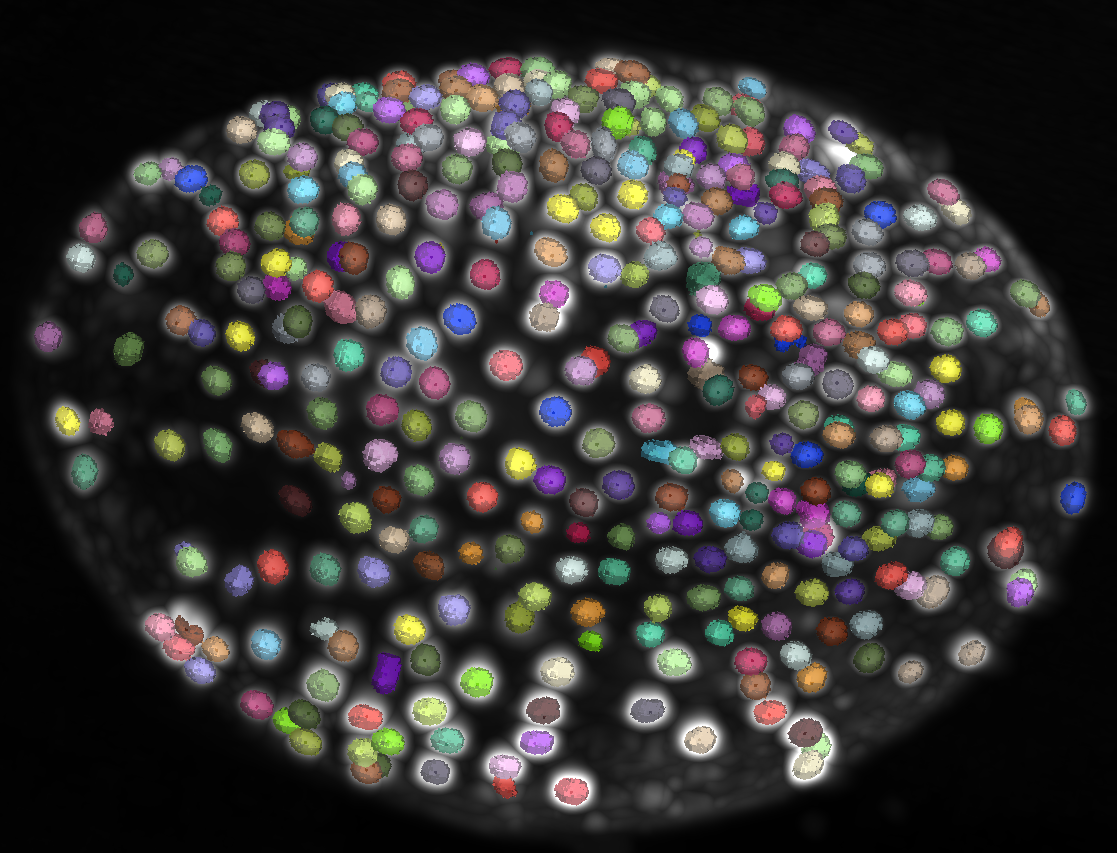

Problems: There are some TINY regions, and bright nuclei are smaller than necessary.

# Conclusions

This algorythm works best for the grid and for later timepoints. Further improvement is necessary. 

Also, keep in mind that this implementation is using brute force to produce a mostly spherical shape, reducing the fidelity of the segment shape, but not entirely. A tradeoff optimization situation.  